# 03 — Loss, Gradients, and Backpropagation (TensorFlow / Keras)

Loss quantifies the mistake; gradients quantify parameter responsibility. Backpropagation is repeated chain rule, not a separate mysterious learning mechanism.


For softmax + cross entropy, the output sensitivity simplifies to
$$\frac{\partial \mathcal L}{\partial z^{(2)}}=\frac{1}{B}(\hat Y-Y).$$
Earlier gradients are obtained by multiplying this sensitivity backward through weights and activation derivatives.


train (5000, 784) test (1000, 784)


2026-09-07 07:30:16.455291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


loss 2.3333323001861572
kernel (784, 16) norm 5.374420642852783
bias (16,) norm 0.6400421261787415
kernel (16, 10) norm 0.9540829062461853
bias (10,) norm 0.9521795511245728


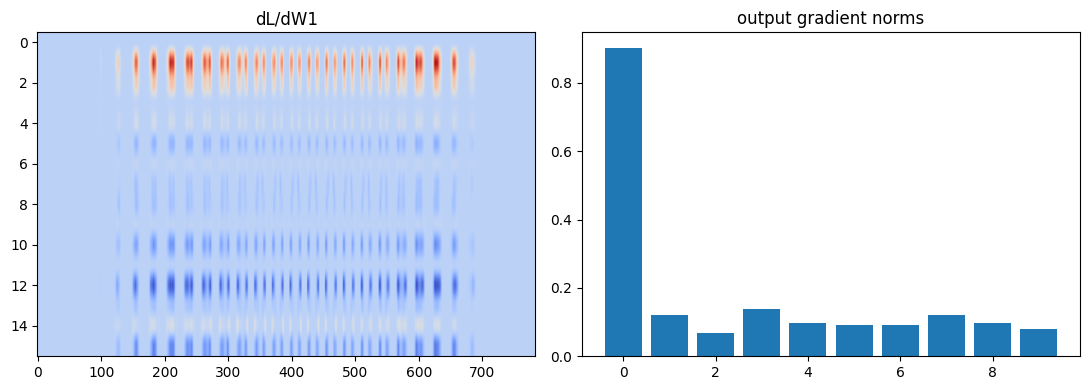

before 2.3333323001861572 after 0.13687251508235931


In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import tensorflow as tf,matplotlib.pyplot as plt
tf.random.set_seed(42);X=tf.constant(x_train[:32]);Y=tf.constant(y_train[:32],dtype=tf.int32);model=tf.keras.Sequential([tf.keras.layers.Input((784,)),tf.keras.layers.Dense(16,activation='relu'),tf.keras.layers.Dense(10)])
with tf.GradientTape() as tape:q=model(X,training=True);loss=tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(Y,q,from_logits=True))
g=tape.gradient(loss,model.trainable_variables);print('loss',float(loss.numpy()))
for v,dv in zip(model.trainable_variables,g):print(v.name,dv.shape,'norm',float(tf.norm(dv).numpy()))
g1=g[0].numpy().T;g2=g[2].numpy().T;fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].imshow(g1,aspect='auto',cmap='coolwarm');axes[1].bar(range(10),np.linalg.norm(g2,axis=1));axes[0].set_title('dL/dW1');axes[1].set_title('output gradient norms');plt.tight_layout();plt.show();opt=tf.keras.optimizers.SGD(.2);old=float(loss.numpy());opt.apply_gradients(zip(g,model.trainable_variables));new=float(tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(Y,model(X),from_logits=True)).numpy());print('before',old,'after',new)


**Cause/effect:** update parameters against the gradient → next forward pass changes → hidden representation changes → class probabilities change → loss changes.

**Production connection:** gradient scale affects convergence speed, instability, training cost, and reproducibility.
